In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

Task 1: Data Understanding & Visualization

In [2]:
train_dir ="/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
test_dir ="/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

Classes: ['cupuacu', 'graviola', 'guarana', 'acai', 'pupunha', 'tucuma']


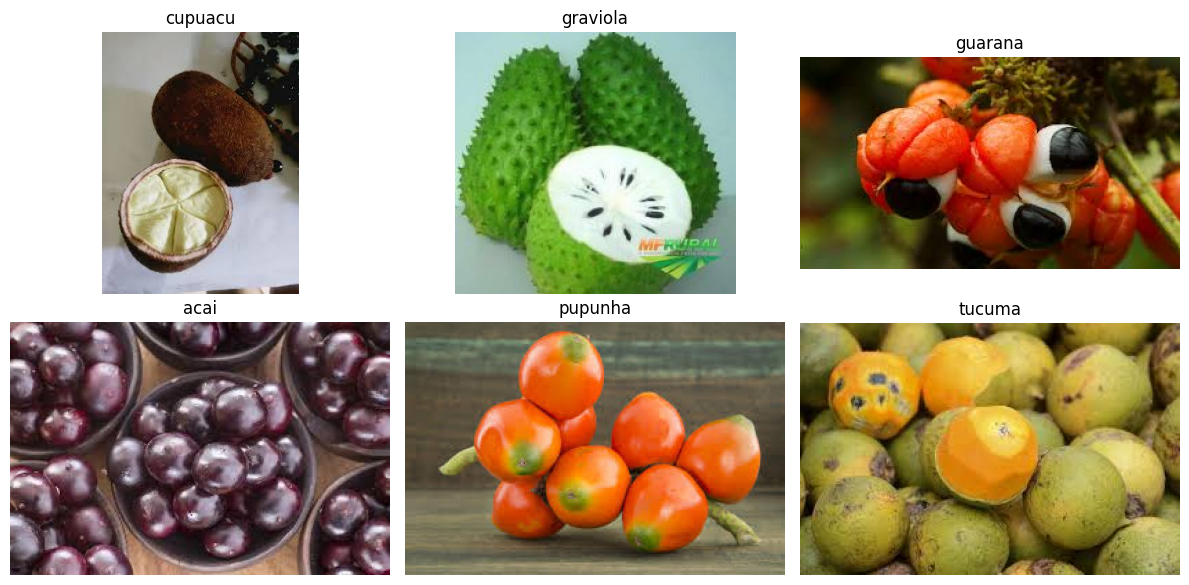

In [7]:
# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image per class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images (2 rows grid)
cols = len(images) // 2 + len(images) % 2

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, cols, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Task 1.2: Check Corrupted Images

In [8]:

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()   # check if corrupted
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data (Keras)

In [10]:

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: Build CNN Model

In [16]:
num_classes = len(os.listdir(train_dir))

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and  Train

In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    ModelCheckpoint("fruit_cnn_model.h5", save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=10)
]

print("Model compiled and callbacks are ready!")

Model compiled and callbacks are ready!


In [31]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

print("Training completed!")

Epoch 1/250


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9410 - loss: 0.2262

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 522ms/step - accuracy: 0.9167 - loss: 0.3183 - val_accuracy: 0.7222 - val_loss: 1.8001
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8750 - loss: 0.3618

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.8750 - loss: 0.4187 - val_accuracy: 0.8333 - val_loss: 0.7353
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 1.0000 - loss: 0.0196

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 566ms/step - accuracy: 1.0000 - loss: 0.0209 - val_accuracy: 0.8333 - val_loss: 0.3896
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 1.0000 - loss: 0.0642 - val_accuracy: 0.8333 - val_loss: 0.4189
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9809 - loss: 0.1077

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/step - accuracy: 0.9583 - loss: 0.1355 - val_accuracy: 0.8333 - val_loss: 0.3857
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 759ms/step - accuracy: 1.0000 - loss: 0.0818 - val_accuracy: 0.8889 - val_loss: 0.4199
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - accuracy: 1.0000 - loss: 0.0477 - val_accuracy: 0.8333 - val_loss: 0.4533
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 1.0000 - loss: 0.0346 - val_accuracy: 0.8333 - val_loss: 0.4405
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 1.0000 - loss: 0.0356 - val_accuracy: 0.8333 - val_loss: 0.4094
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 1.0000 - loss: 0.0206

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 0.8889 - val_loss: 0.3831
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.8333 - val_loss: 0.3935
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8333 - val_loss: 0.4034
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 791ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8333 - val_loss: 0.4051
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8333 - val_loss: 0.4167
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8333 - val_loss: 0.4208
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 1.0000 - loss: 7.8946e-04 - val_accuracy: 0.8333 - val_loss: 0.4155
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 1.0000 - loss: 5.8824e-04 - val_accuracy: 0.8333 

Plot Accuracy & Loss

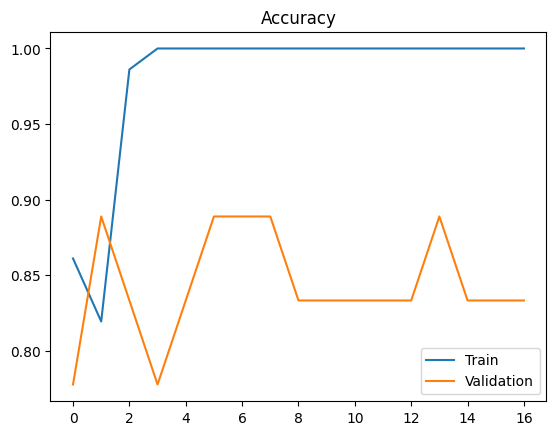

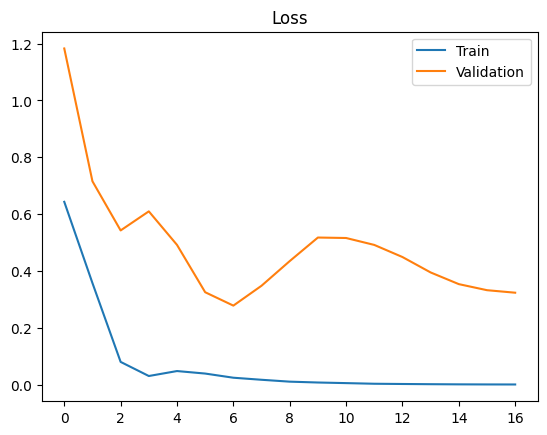

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

Task 5: Evaluate the Model

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8333 - loss: 0.5910
Test Accuracy: 0.8333333134651184
Test Loss: 0.5909539461135864


Task 6: Save & Load the Model

In [27]:
from tensorflow.keras.models import load_model

# Save the trained model
model.save("fruit_classifier_model.h5")
print("Model saved as fruit_classifier_model.h5")



Model saved as fruit_classifier_model.h5


In [28]:
# Load the saved model
loaded_model = load_model("fruit_classifier_model.h5")
print("Model loaded successfully!")

# Re-evaluate on test set
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_acc:.4f}")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step - accuracy: 0.6667 - loss: 0.9546
Loaded Model Test Loss: 0.9546
Loaded Model Test Accuracy: 0.6667


Task 7: Predictions & Classification Report

In [30]:
import numpy as np
from sklearn.metrics import classification_report

# Lists to store true labels and predictions
y_true = []
y_pred = []

# Loop through test dataset
for images, labels in test_ds:
    preds = loaded_model.predict(images)  # predicted probabilities
    preds = np.argmax(preds, axis=1)      # convert to class labels

    y_true.extend(labels.numpy())         # actual labels
    y_pred.extend(preds)                  # predicted labels

# Print Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Classification Report:

              precision    recall  f1-score   support

     cupuacu       0.67      0.80      0.73         5
    graviola       0.57      0.80      0.67         5
     guarana       0.71      1.00      0.83         5
        acai       0.80      0.80      0.80         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.63        30
weighted avg       0.71      0.67      0.63        30

